# Fine Tune Efficientnet with LSTM

In [1]:
import os, pathlib
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
from datetime import datetime
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel as ConfigBaseModel
import tensorflow as tf
print("tensorflow:", tf.__version__)
import keras_cv
print("keras_cv:", keras_cv.__version__)
import tensorflow_io as tfio
print("tfio:", tfio.__version__)
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from tensorflow.keras.layers import *

tensorflow: 2.18.0


/Users/camcortes/Library/Caches/pypoetry/virtualenvs/birds-sounds-images-gIa9Kkaf-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


keras_cv: 0.9.0
tfio: 0.37.1


In [2]:
strategy = tf.distribute.MirroredStrategy()
print("Strategy:", strategy)
print("Number of replicas:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
Strategy: <tensorflow.python.distribute.mirrored_strategy.MirroredStrategy object at 0x17a86eb50>
Number of replicas: 1


In [3]:
sorted(tf.config.list_logical_devices())

[LogicalDevice(name='/device:CPU:0', device_type='CPU')]

# Config

In [4]:
from typing import Tuple
from pydantic import BaseModel

class Config(BaseModel):
    ## general
    run_ts: str = datetime.now().strftime("%Y-%d-%m %H:%M:%S")
    debug: bool = False
    model_name: str = "transfer_learn_simple"
    test_size: float = 0.2
    seed: int = 887
    fit_verbose: int = 1 if (os.environ.get('KAGGLE_KERNEL_RUN_TYPE') == "Interactive") else 2

    ## data
    dataset_dir: str = "./data_spec/train_spectograms.csv"
    path_data: str = "./data_spec/train_spectograms.csv"
    label: str = "label"
    n_label: int = 37
    img_size: Tuple[int, int] = (128, 256)
    channels: int = 1
    img_shape: Tuple[int, int, int] = (*img_size, channels)

    ## model
    base_model_weights: str = "imagenet"
    dropout: float = 0.20

    ## training
    label_smoothing: float = 0.05
    shuffle_size: int = 1028
    steps_per_epoch: int = 300
    batch_size: int = 128  # 16 * strategy.num_replicas_in_sync
    valid_batch_size: int = batch_size
    epochs: int = 80
    patience: int = 4
    monitor: str = "val_loss"  # val_loss
    monitor_mode: str = "auto"
    lr: float = 1e-4

    ## aug
    aug_proba: float = 0.8

# Crear una instancia de la configuración
cfg = Config()
cfg.dict()

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_26841/2293403790.py:43: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  cfg.dict()


{'run_ts': '2025-19-01 22:48:46',
 'debug': False,
 'model_name': 'transfer_learn_simple',
 'test_size': 0.2,
 'seed': 887,
 'fit_verbose': 2,
 'dataset_dir': './data_spec/train_spectograms.csv',
 'path_data': './data_spec/train_spectograms.csv',
 'label': 'label',
 'n_label': 37,
 'img_size': (128, 256),
 'channels': 1,
 'img_shape': (128, 256, 1),
 'base_model_weights': 'imagenet',
 'dropout': 0.2,
 'label_smoothing': 0.05,
 'shuffle_size': 1028,
 'steps_per_epoch': 300,
 'batch_size': 128,
 'valid_batch_size': 128,
 'epochs': 80,
 'patience': 4,
 'monitor': 'val_loss',
 'monitor_mode': 'auto',
 'lr': 0.0001,
 'aug_proba': 0.8}

# Preparation

## Load data

In [5]:
data = pd.read_csv(cfg.path_data)
data["path_img"] = data["image_path"]
if cfg.debug:
    data = data.iloc[:1000]
data.sample(6)
data.shape

(33729, 4)

## Dataset

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def show_img_stats(img):
    if isinstance(img, tf.Tensor):
        print((img.shape, img.dtype, img.numpy().min(), img.numpy().max()))
    elif isinstance(img, np.array):
        print((img.shape, img.dtype, img.min(), img.max()))
    else:
        print(f"unexpected type: {type(img)}")


def read_image(path_img):
    img_data = tf.io.read_file(path_img)
    img = tf.io.decode_jpeg(img_data, channels=cfg.channels)
    # Redimensionar la imagen a las dimensiones deseadas
    img = tf.image.resize(img, cfg.img_size)
    img = tf.cast(img, tf.float32)
    return img


from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(data.label)

def decode_label(label):
    integer_encoded = label_encoder.transform(label)
    return tf.one_hot(integer_encoded, depth=cfg.n_label)

In [7]:
from keras_cv.layers import BaseImageAugmentationLayer

class RandomRowMask(keras_cv.layers.BaseImageAugmentationLayer):
    def __init__(self, param=10, max_num_mask=3, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    def augment_image(self, image, transformation=None, **kwargs):
        num = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)
        
        def condition(i, img):
            return tf.less(i, num)
        
        def body(i, img):
            img = tfio.audio.time_mask(tf.squeeze(img), param=self.param)
            img = tf.reshape(img, cfg.img_shape)
            return tf.add(i, 1), img
        
        _, image = tf.while_loop(
            condition,
            body,
            loop_vars=[0, image],
            shape_invariants=[tf.TensorShape([]), tf.TensorShape(cfg.img_shape)]
        )
        
        return image

class RandomColumnMask(keras_cv.layers.BaseImageAugmentationLayer):
    def __init__(self, param=40, max_num_mask=2, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    def augment_image(self, image, transformation=None, **kwargs):
        num = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)
        
        def condition(i, img):
            return tf.less(i, num)
        
        def body(i, img):
            img = tfio.audio.freq_mask(tf.squeeze(img), param=self.param)
            img = tf.reshape(img, cfg.img_shape)
            return tf.add(i, 1), img
        
        _, image = tf.while_loop(
            condition,
            body,
            loop_vars=[0, image],
            shape_invariants=[tf.TensorShape([]), tf.TensorShape(cfg.img_shape)]
        )
        
        return image
    

augmenter = keras_cv.layers.Augmenter(
    layers=[
        keras_cv.layers.RandomBrightness(factor=0.2),
        #keras_cv.layers.RandomContrast(factor=0.2),
        keras_cv.layers.GridMask(ratio_factor=(0.05, 0.10)),
        keras_cv.layers.RandomGaussianBlur(kernel_size=2, factor=0.1),
        RandomRowMask(10, 3),
        RandomColumnMask(40, 2)
    ]
)

def augment_image(img):
    if tf.random.uniform([]) <= cfg.aug_proba:
        img = augmenter(img)
    return img

In [8]:
def create_dataset(data, include_label=True, repeat=False, shuffle=False, augment=False, prefetch=False, batch_size=None):
    slices = data["path_img"].values
    read_func = read_image
    aug_func = augment_image
    if include_label:
        slices = slices, decode_label(data[cfg.label].values)
        read_func = lambda path_img, label: (read_image(path_img), label)
        aug_func = lambda img, label: (augment_image(img), label)
    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(read_func, num_parallel_calls=AUTOTUNE)
    if repeat: ds = ds.repeat()
    if shuffle: ds = ds.shuffle(buffer_size=cfg.shuffle_size)
    if augment: ds = ds.map(aug_func, num_parallel_calls=AUTOTUNE)
    if batch_size: ds = ds.batch(batch_size)
    if prefetch: ds = ds.prefetch(AUTOTUNE)
    return ds

In [9]:
def create_training_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=True,
        shuffle=True,
        augment=True,
        prefetch=True,
        batch_size=cfg.batch_size,
    )


def create_validation_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=False,
        shuffle=False,
        augment=False,
        prefetch=True,
        batch_size=cfg.valid_batch_size,
    )

#### Check augmentation

In [10]:
rec = data.sample(1).iloc[0]
rec

label                                         Troglodytes aedon
image_path    ./images_spectograms/test/Troglodytes aedon/69...
db                                                         test
path_img      ./images_spectograms/test/Troglodytes aedon/69...
Name: 478, dtype: object

(TensorShape([128, 256, 1]), tf.float32, np.float32(2.8789062), np.float32(254.22656))


(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(235.02669))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(232.92802))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(228.43541))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(212.00879))


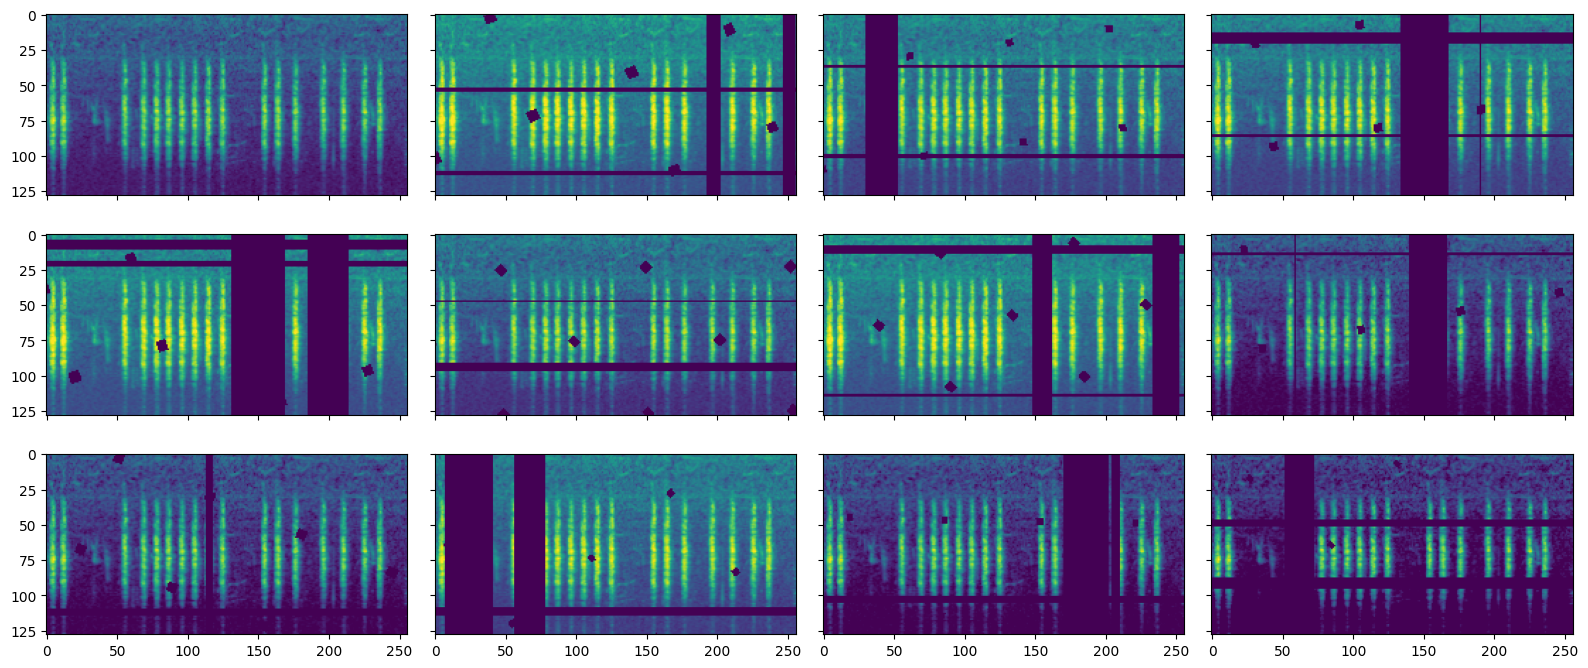

In [11]:
img = read_image(rec.image_path)
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 7))
for i, ax in enumerate(axs.flat):
    if i == 0:
        ax.imshow(img, cmap='viridis')
        show_img_stats(img)
    else:
        img1 = augmenter(img)
        ax.imshow(img1, cmap='viridis')
        show_img_stats(img1)
plt.tight_layout()
plt.show()   

#### Check dataset

In [12]:
dev_data = data.sample(500)
dev_ds = create_training_dataset(dev_data)
dev_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 37), dtype=tf.float32, name=None))>

In [13]:
elem = next(iter(dev_ds.take(1)))
elem[1]

<tf.Tensor: shape=(128, 37), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(224.05836))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(203.36218))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(205.49786))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(208.2391))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(233.5797))


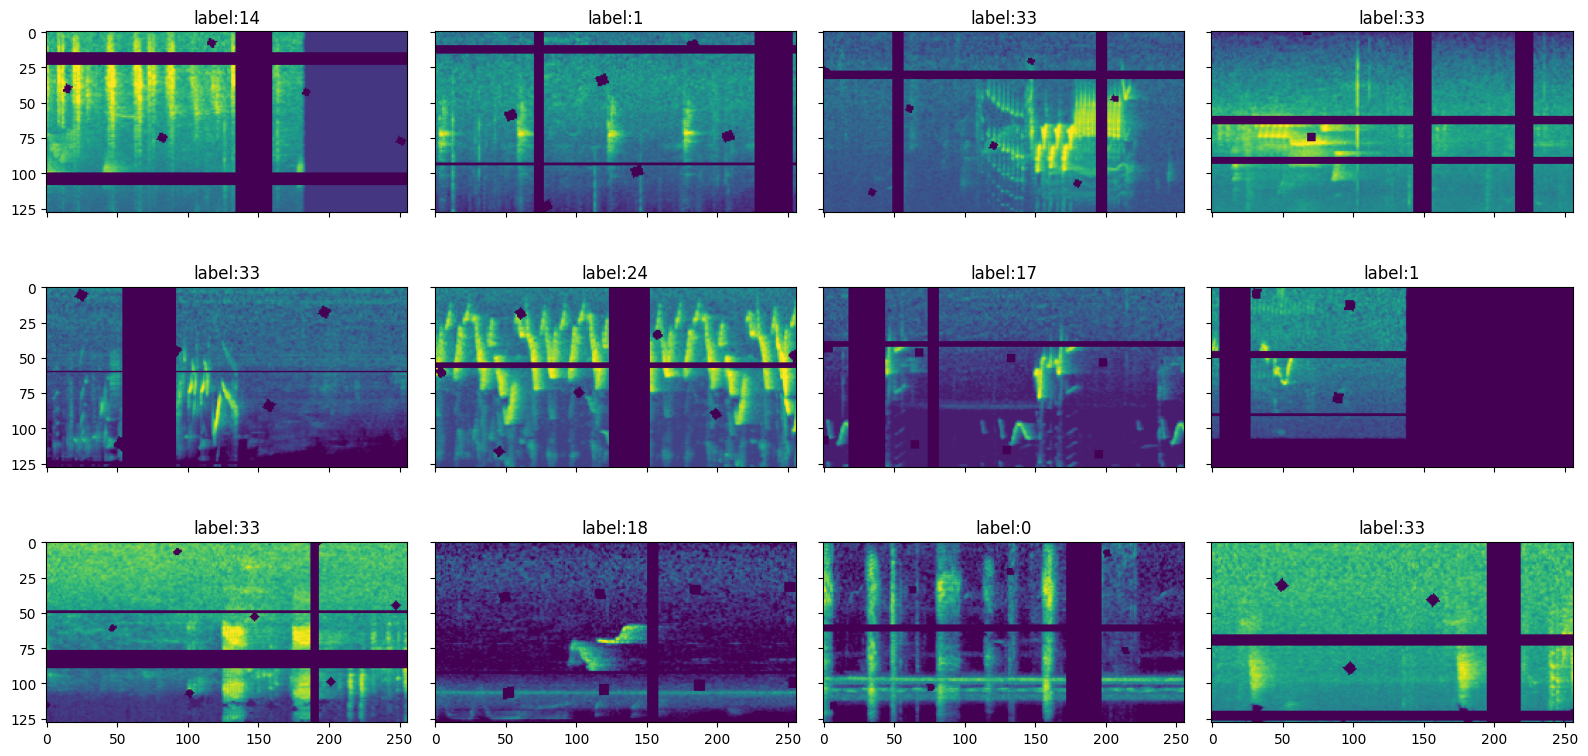

In [14]:
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 8))
for i, ax in enumerate(axs.flat):
    img = elem[0][i]
    show_img_stats(img)
    ax.imshow(img, cmap="viridis")
    ax.set_title(f"label:{np.argmax(elem[1][i].numpy())}")
plt.tight_layout()
plt.show()

# Neural network

In [15]:
from tensorflow.keras.applications.efficientnet import EfficientNetB7 as BaseModel
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, losses, metrics, callbacks

In [16]:
def create_model(lr):
    inputs = layers.Input(shape=cfg.img_shape, dtype=tf.float32)
    x = layers.Lambda(lambda img: tf.image.grayscale_to_rgb(img))(inputs)
    x = layers.Lambda(preprocess_input, name="preprocess_input")(x)
    base_model = BaseModel(include_top=False, weights=cfg.base_model_weights, pooling="avg")
    base_model.trainable = True
    fine_tune_at = 200  # Specify the number of layers to fine-tune
    for layer in base_model.layers[:-fine_tune_at]:
        layer.trainable = False
    x = base_model(x)
    #x = base_model(x, training=False)
   # x = base_model.output
    x = layers.Flatten()(x)
    x =layers.Reshape((1, 2560))(x)
    x = layers.LSTM(256, return_sequences=False)(x)
    x = layers.Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(cfg.n_label, name='logits')(x)

#     x = layers.Dropout(cfg.dropout, name="top_dropout")(x)
#     outputs = layers.Dense(cfg.n_label,kernel_regularizer=regularizers.l2(0.001), name="logits")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=cfg.model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr,beta_1=0.9,beta_2=0.999,epsilon=1e-08),
        loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=cfg.label_smoothing),
        metrics=['acc']
    )
    return model

#### Check model

In [17]:
tf.keras.backend.clear_session()
with strategy.scope():
    dev_model = create_model(lr=cfg.lr)
dev_model.summary(line_length=120)

Model: "transfer_learn_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_layer (InputLayer)                            │ (None, 128, 256, 1)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lambda (Lambda)                                     │ (None, 128, 256, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ preprocess_input (Lambda)                           │ (None, 128, 256, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ efficientnetb7 (Functional)                         │ (None, 2560)                           │            64,097,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ flatten (Flatten)                                   │ (None, 2560)                           │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ reshape (Reshape)                                   │ (None, 1, 2560)                        │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lstm (LSTM)                                         │ (None, 256)                            │             2,884,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout (Dropout)                                   │ (None, 256)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dense (Dense)                                       │ (None, 64)                             │                16,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ logits (Dense)                                      │ (None, 37)                             │                 2,
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 67,001,148 (255.59 MB)

 Trainable params: 46,517,061 (177.45 MB)

 Non-trainable params: 20,484,087 (78.14 MB)

In [18]:
dev_model.predict(dev_ds.take(1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


array([[-0.05859718,  0.00892074, -0.15084653, ..., -0.040283  ,
         0.04532688,  0.10859156],
       [-0.03506824,  0.0061551 , -0.17694375, ..., -0.05310106,
         0.02100145,  0.12291088],
       [-0.10310829, -0.04186596, -0.20040269, ..., -0.06106238,
         0.08645874,  0.11039045],
       ...,
       [-0.04665569, -0.02022943, -0.19526497, ..., -0.0535276 ,
         0.05482979,  0.17301063],
       [-0.13097897,  0.02641762, -0.2669214 , ..., -0.04912914,
         0.09246691,  0.12835445],
       [-0.07586673, -0.07622585, -0.12096031, ..., -0.03100567,
        -0.08601283,  0.10394143]], dtype=float32)

In [19]:
dev_model.evaluate(dev_ds.take(1), return_dict=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - acc: 0.0234 - loss: 3.6188


{'acc': 0.0234375, 'loss': 3.618793487548828}

# Training utils

In [20]:
def get_callbacks(filepath):
    """Get callbacks"""
    cbs = [
        callbacks.ModelCheckpoint(
            filepath=filepath,
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            save_best_only=True,
            save_weights_only=True            
        ),
        callbacks.EarlyStopping(
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            patience=cfg.patience,
            restore_best_weights=False,
        ),
    ]
    return cbs


def show_history(history):
    """Show history"""
    history_frame = pd.DataFrame(history.history)
    history_frame.index = pd.RangeIndex(1, len(history_frame) + 1, name="epoch")
    display(history_frame.style\
        .highlight_min(color='lightgreen', subset=['val_loss'])\
        .highlight_max(color='lightgreen', subset=['val_acc'])
    )
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    history_frame.loc[:, ['loss', 'val_loss']].plot(ax=ax[0], title='loss')
    history_frame.loc[:, ['acc', 'val_acc']].plot(ax=ax[1], title='acc')
    plt.tight_layout()
    plt.show()
    
    
def compute_oof(model, valid_df):
    """Compute OOF"""
    valid_ds = create_validation_dataset(valid_df)
    oof_pred = model.predict(valid_ds, verbose=False)
    oof_pred = pd.DataFrame(tf.nn.sigmoid(oof_pred).numpy(), index=valid_df.index)
    oof = pd.concat({"y_true": valid_df[cfg.label], "y_pred": oof_pred}, axis=1)
    return oof    

In [21]:
def run_training(train_df, valid_df, model_name):
    """Run training"""
    # prepare dataset
    train_ds = create_training_dataset(train_df)
    valid_ds = create_validation_dataset(valid_df)
    # create model
    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_model(lr=cfg.lr)
    # fit
    steps_per_epoch = cfg.steps_per_epoch
    print("steps_per_epoch:", steps_per_epoch)
    path_weight = f"./model/weights_lstm_{model_name}.weights.h5"
    print("path_weights:", path_weight)
    hist = model.fit(
        train_ds,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_ds,
        callbacks=get_callbacks(path_weight),
        verbose=cfg.fit_verbose
    )
    # restore
    model.load_weights(path_weight)
#     # save full model
#     does not work: https://github.com/keras-team/keras/pull/17498 
#     path_model = f"/kaggle/working/{model_name}"
#     print("path_model:", path_model)
#     model.save(path_model)
    # compute oof
    oof = compute_oof(model, valid_df)
    return hist, oof, model

# Run training
Let us start by training just a single split.

In [22]:
train_df, valid_df = train_test_split(data, test_size=cfg.test_size, stratify=data[cfg.label])
valid_df, test_df = train_test_split(valid_df, test_size=0.5, stratify=valid_df[cfg.label])
print(f"Split: {len(train_df)} vs {len(valid_df)}")
model_name = f"{cfg.model_name}"
print(f"model_name: {model_name}")

Split: 26983 vs 3373
model_name: transfer_learn_simple


In [23]:
hist, oof,model = run_training(train_df, valid_df, model_name)

steps_per_epoch: 300
path_weights: ./model/weights_lstm_transfer_learn_simple.weights.h5
Epoch 1/80

Epoch 1: val_loss improved from inf to 1.84717, saving model to ./model/weights_lstm_transfer_learn_simple.weights.h5
300/300 - 3176s - 11s/step - acc: 0.3466 - loss: 2.6711 - val_acc: 0.5600 - val_loss: 1.8472
Epoch 2/80


KeyboardInterrupt: 

,loss,acc,val_loss,val_acc
epoch,,,,
1,4.809622,0.143320,4.006694,0.258501
2,3.914333,0.276953,3.474257,0.367676
3,3.527403,0.347461,3.136829,0.427048
4,3.260497,0.399199,2.864822,0.472415
5,3.073010,0.431758,2.692939,0.504163
6,2.910499,0.460723,2.530002,0.539647
7,2.778760,0.487637,2.412047,0.558244
8,2.659476,0.508789,2.298364,0.581122
9,2.566556,0.528711,2.206794,0.604544


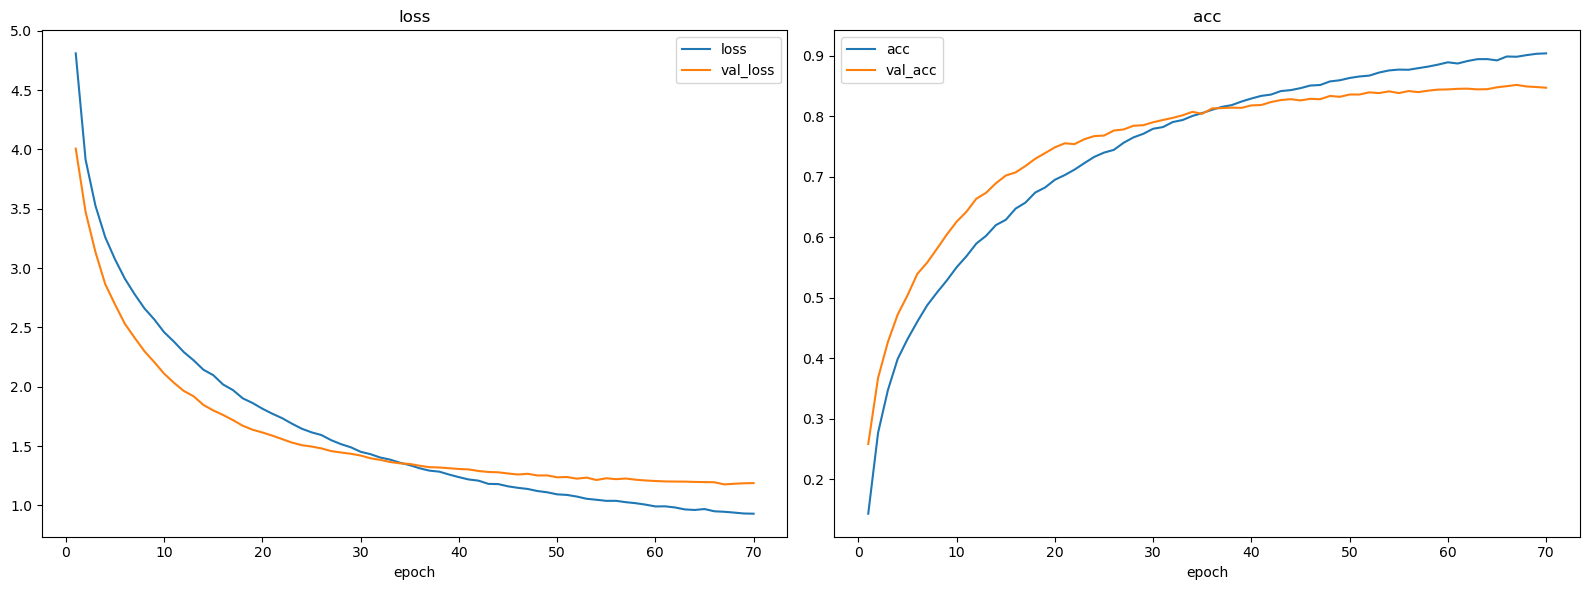

In [25]:
show_history(hist)

In [26]:
oof.to_csv("./model/lstm_transfer_learn_simple.csv")

In [27]:
# tf.keras.backend.clear_session()
# with strategy.scope():
#     model = create_model(lr=cfg.lr)
    
# model.load_weights("/kaggle/input/eff-lstm-84/weights_EFF-b0-LSTM.h5")

# Evaluation

In [28]:
test_ds = create_validation_dataset(test_df)

In [29]:
true_labels = []
i=0
test_ds_size = test_ds.cardinality().numpy()
print(test_ds_size)
for batch in test_ds:
    _, batch_labels = batch  # assuming that labels are the second element of the batch tuple
    true_labels.extend(batch_labels.numpy().tolist())
    i+=1

101


In [30]:
pred_labels = model.predict(test_ds, verbose=cfg.fit_verbose, workers=os.cpu_count(), use_multiprocessing=True)

101/101 - 53s - 53s/epoch - 523ms/step


In [31]:
from sklearn.metrics import average_precision_score
mAP_score = average_precision_score(true_labels, pred_labels, average='macro')
average_precision = average_precision_score(true_labels, pred_labels)
print("Average precision ", average_precision)
print("Mean average precision ", mAP_score)

Average precision  0.8466304524636623
Mean average precision  0.8466304524636623


In [32]:
from sklearn.metrics import accuracy_score
true_label = np.array(true_labels)
true_label = np.argmax(true_labels, axis=1)

pred_label=tf.argmax(pred_labels, axis=1).numpy()
# # assume y_true and y_pred are your true and predicted labels, respectively
acc = accuracy_score(true_label, pred_label)
print(acc)

0.8508403361344538


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
precision = precision_score(true_label, pred_label, average='macro')
recall = recall_score(true_label, pred_label,  average='macro')
f1_score = f1_score(true_label, pred_label, average='macro')

print("Precision: ", precision)
print("Recall: ", recall)
print("F1_score: ", f1_score)

true_label_str = label_encoder.inverse_transform(true_label)
pred_label_str = label_encoder.inverse_transform(pred_label)

# classification_report
print(classification_report(true_label_str, pred_label_str))

Precision:  0.8633836619688716
Recall:  0.827280676038803
F1_score:  0.8395946864514754
